# From Scanned Page to Machine-Readable Text
### *Daga takarda zuwa data* — Deep Learning Indaba, Lagos 2026

Much of Africa's written record exists only on paper: newspapers, manuscripts, court records, school and church registers. In this demo we take one old newspaper page and follow the steps that turn it into text a computer can use.

The question for the next 12 minutes:

> *"We have the archives. Is that not enough?"*

The plan:
1. **The asset** — what an archive really holds
2. **The work** — the steps that turn a scan into text
3. **The result, and the gap** — what we recovered, and what is still missing

Note: cells with a grey title contain setup code. They are collapsed to keep the page short. Double-click any of them to read the code inside. Every other cell runs in front of you.

In [1]:
#@title Setup — installs and data (double-click to read the code) { display-mode: "form" }
# Installs the Tesseract OCR engine and Python helpers, downloads the workshop
# data, and defines two small utilities.
import os, subprocess, sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run(["apt-get", "install", "-y", "-q", "tesseract-ocr"], capture_output=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pytesseract", "jiwer"],
                   capture_output=True)

REPO_URL = "https://github.com/abumafrim/indaba2026-ocr-audio"  # update if you fork
if os.path.exists("../data"):
    ROOT = ".."
elif os.path.exists("data"):
    ROOT = "."
else:
    subprocess.run(["git", "clone", "-q", REPO_URL + ".git"], check=True)
    ROOT = "indaba2026-ocr-audio"
DATA = os.path.join(ROOT, "data")

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pytesseract
from jiwer import cer

# The repo ships its own OCR models (data/tessdata: eng + yor), so Tesseract
# reads them from a relative path — no system folders involved.
os.environ["TESSDATA_PREFIX"] = os.path.abspath(os.path.join(DATA, "tessdata"))

def show(*imgs, titles=None, height=5.5):
    """Display 1-3 images side by side."""
    fig, axes = plt.subplots(1, len(imgs), figsize=(7.5 * len(imgs), height))
    for ax, im, t in zip(np.atleast_1d(axes), imgs, (titles or [""] * len(imgs))):
        ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        ax.set_title(t, fontsize=13)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def CER(truth_text, ocr_text):
    """Character error rate, in % — how far the OCR text is from the true text."""
    squash = lambda s: " ".join(s.split())
    return round(cer(squash(truth_text), squash(ocr_text)) * 100, 1)

truth = open(os.path.join(DATA, "newspaper_ground_truth.txt")).read()
print("Setup complete.  Tesseract", pytesseract.get_tesseract_version())

Setup complete.  Tesseract 5.5.3


## Part 1 — The asset

Text reaches a computer in three main ways. It was typed on a computer from the start. Or someone typed it up later. Or it was scanned and converted. For most African-language text from before the 2000s, scanning is the only option.

Here is our page: a 1972 Hausa newspaper (made for this demo), the way it comes off a scanner in a media-house archive. It is tilted, it is stained, and the back page shows through the paper.

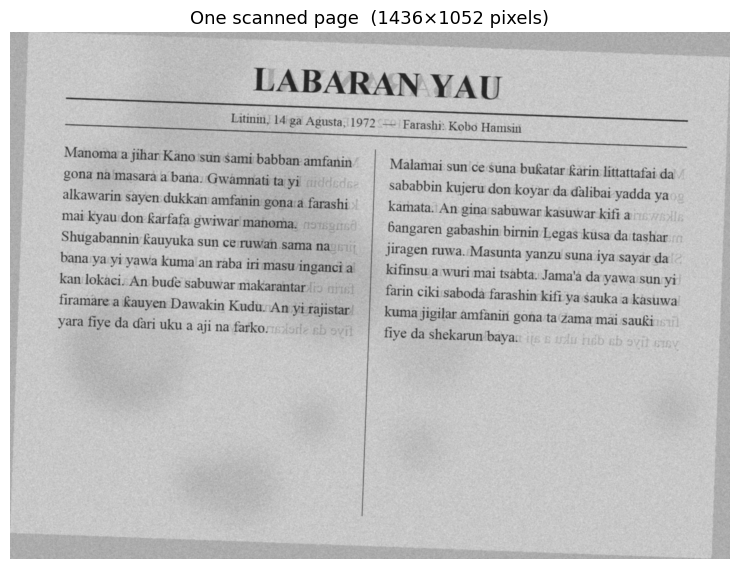

In [2]:
scan = cv2.imread(os.path.join(DATA, "newspaper_raw.png"), cv2.IMREAD_GRAYSCALE)
show(scan, titles=[f"One scanned page  ({scan.shape[1]}×{scan.shape[0]} pixels)"], height=8)

A person can read this page. Can a machine? Let us ask Tesseract, the most widely used free OCR engine, to read the page exactly as it was scanned.

In [3]:
raw_text = pytesseract.image_to_string(scan, lang="eng")

print(raw_text[:400])
print("…")
print(f"\nCharacter error rate: {CER(truth, raw_text)} % of the characters are wrong")

LABARAN YAU

Litinin 14\ga Agusta, 1972 =~ Farashi: Kobo Hamsin

Manoma a jihar Kano'sun sami babban amfanin Malamai sun ce suna bukatar Karin littattafai dal
sababbin kujeru don koyar da dalibai yadda ya
kamata.\An gina sabuwar kasuwar kifi a
bangaren gabashin birnin Legas kusa da tashar
Jiragen ruwa. Masunta yanzu suna iya sayar da
kifinsu.a wuri mai tsabta. Jama'a da yawa sun yi
farin ciki sabo
…

Character error rate: 62.6 % of the characters are wrong


More than half of the characters are wrong. At this quality the page cannot be searched, translated, or used to train a model.

Having the data is not the same as being able to use it. So what does it take?

## Part 2 — The work

Each step below is a decision someone makes, code someone runs, and work someone is paid to do.

### Step 1 — Remove the noise
To the machine, the stains, the paper texture and the scanner noise all look like ink.

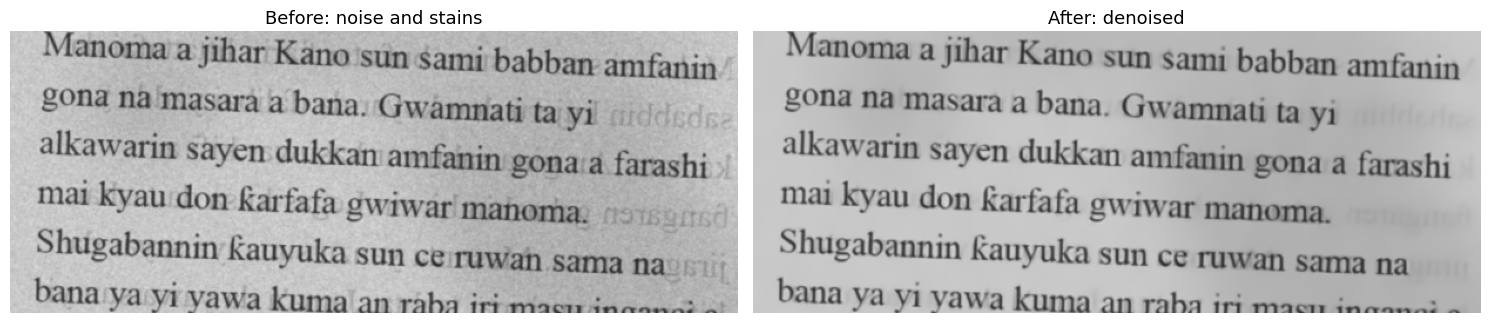

In [4]:
denoised = cv2.fastNlMeansDenoising(scan, h=15)

zoom = (slice(230, 470), slice(80, 700))   # a few lines from column 1, enlarged
show(scan[zoom], denoised[zoom], titles=["Before: noise and stains", "After: denoised"], height=4)

### Step 2 — Separate ink from paper
This step is called *binarization*: every pixel becomes pure black or pure white. It also removes the text showing through from the back page.

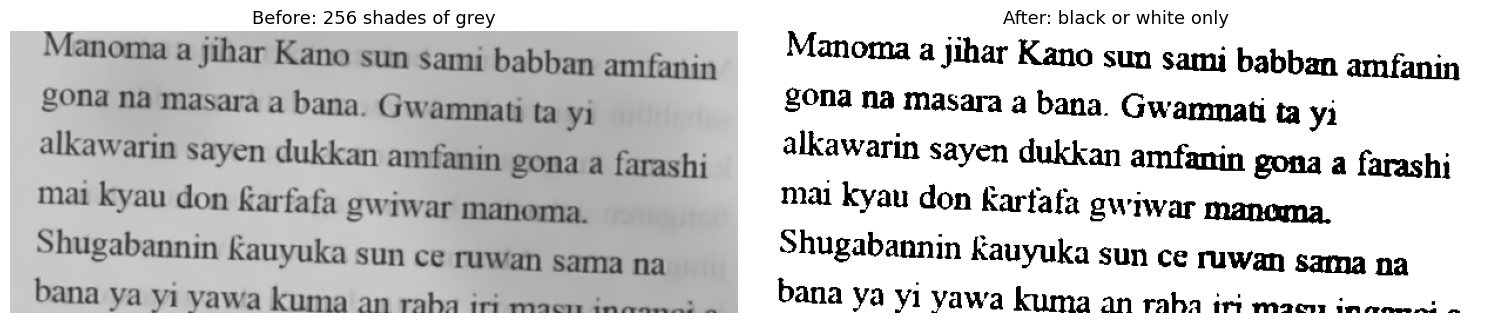

In [5]:
_, bw = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show(denoised[zoom], bw[zoom], titles=["Before: 256 shades of grey", "After: black or white only"], height=4)

### Step 3 — Straighten the page
The page went into the scanner at an angle. OCR reads in straight lines, so we measure the tilt of the text and rotate the page back.

Measured tilt: 2.1°


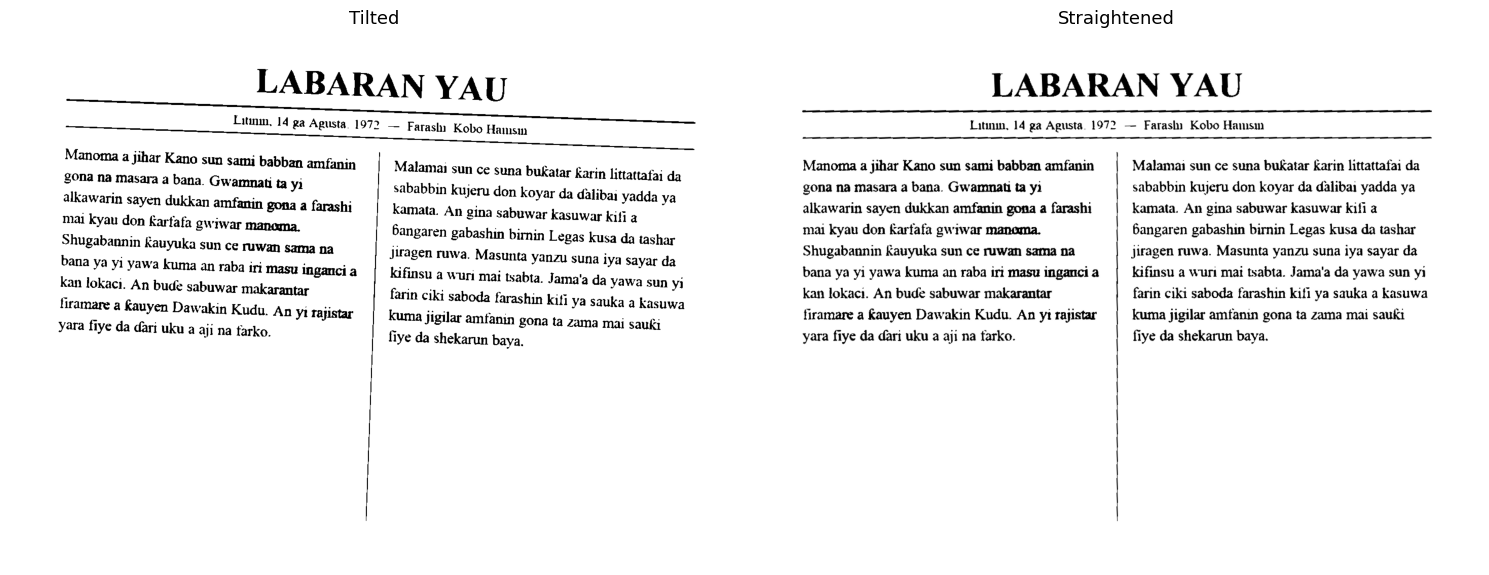

In [6]:
ink = np.column_stack(np.where(bw < 128))            # coordinates of every ink pixel
angle = cv2.minAreaRect(ink[:, ::-1])[-1]
if angle > 45:
    angle -= 90

h, w = bw.shape
M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
straight = cv2.warpAffine(bw, M, (w, h), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=255)

print(f"Measured tilt: {angle:.1f}°")
show(bw, straight, titles=["Tilted", "Straightened"], height=6)

### Read it again
Same page. Same OCR engine. Only the preparation changed.

In [7]:
clean_text = pytesseract.image_to_string(straight, lang="eng")

print(clean_text[:400])
print("…")
print(f"\nBefore preparation: {CER(truth, raw_text):>5} % of characters wrong")
print(f"After preparation : {CER(truth, clean_text):>5} % of characters wrong")

LABARAN YAU

Litmm, 14 ga Agusta. 1972 — Farashi Kobo Hamsm

Manoma a jihar Kano sun sami babban amfanin
gona na masara a bana. Gwammnati ta yi
alkawarin sayen dukkan amfanin gona a farashi
mai kyau don Karfafa gwiwar manoma.
Shugabannin Kauyuka sun ce ruwan sama na
bana ya yi yawa kuma an raba iri masu inganci a
kan lokaci. An bude sabuwar makarantar
firamare a Kauyen Dawakin Kudu. An yi rajistar
…

Before preparation:  62.6 % of characters wrong
After preparation :   2.4 % of characters wrong


From about 60% wrong to about 2% wrong. The page can now be searched, translated and used for training. That improvement is the value the preparation added.

## Part 3 — The gap software cannot close

Look closely at the result. Hausa uses the letters **ƙ, ɗ and ɓ**, and they change meaning: *ɗari* (hundred) is not *dari* (cold weather). Did these letters survive?

In [8]:
hooked = sum(clean_text.count(ch) for ch in "ƙɗɓƘƊƁ")
print(f"Hooked letters (ƙ ɗ ɓ) in the true text  : {sum(truth.count(c) for c in 'ƙɗɓƘƊƁ')}")
print(f"Hooked letters in the OCR output         : {hooked}\n")

for got, wanted in [("Karfafa", "ƙarfafa"), ("dari uku", "ɗari uku"), ("6angaren", "ɓangaren")]:
    line = next((l for l in clean_text.splitlines() if got.lower() in l.lower()), "")
    print(f'  wanted "{wanted}" → got "{got}"   in: {line.strip()}')

Hooked letters (ƙ ɗ ɓ) in the true text  : 10
Hooked letters in the OCR output         : 0

  wanted "ƙarfafa" → got "Karfafa"   in: mai kyau don Karfafa gwiwar manoma.
  wanted "ɗari uku" → got "dari uku"   in: yara fiye da dari uku a aji na farko.
  wanted "ɓangaren" → got "6angaren"   in: 


All of them are gone, and no error message told us. The reason: we read a Hausa newspaper with an *English* OCR model. And we had no other choice:

In [9]:
langs = pytesseract.get_languages()
print("Language models available here:", langs)
print("\nTesseract offers about 130 language models. Hausa ('hau') is not one of them.")
print("About 80 million people speak Hausa. No one has built the training data yet.")

Language models available here: ['eng', 'yor']

Tesseract offers about 130 language models. Hausa ('hau') is not one of them.
About 80 million people speak Hausa. No one has built the training data yet.


Where a community *has* built the data, the same free software keeps the language intact. Yoruba has a Tesseract model. Compare the two models on a Yoruba sentence with full tone marks:

In [10]:
ysnippet = cv2.imread(os.path.join(DATA, "yoruba_snippet.png"), cv2.IMREAD_GRAYSCALE)
ytruth = open(os.path.join(DATA, "yoruba_ground_truth.txt")).read().strip()

print(f"true text    : {ytruth}")
print(f"English model: {' '.join(pytesseract.image_to_string(ysnippet, lang='eng').split())}")
print(f"Yoruba model : {' '.join(pytesseract.image_to_string(ysnippet, lang='yor').split())}")

true text    : Ọjọ́ dára púpọ̀. Àwọn ọmọdé ń kọrin ní ilé ìwé. Olùkọ́ fẹ́ràn iṣẹ́ rẹ̀.
English model: Ojé dara pupd. Awon omodé f korin ni ilé iwé. OlUk6 féran isé ré.
Yoruba model : Ọjọ dára púpò. Àwọn ọmọdé n kọrin ní ilé ìwé. Olùké fẹràn iṣé rẹ̀.


The English model drops the tone marks. The Yoruba model keeps most of them, because people collected Yoruba training data and built a model with it. **Models exist only for languages that have datasets.**

### Why this matters for the continent

When pages become text at scale:

- **Archives become searchable** — a journalist can find every mention of a town across 40 years of print.
- **The text becomes training data** — machine translation, spell checkers and LLMs for African languages are built from text like this.
- **Heritage is preserved** — paper burns and fades; text files can be copied.
- **Knowledge becomes discoverable** — data that no one can find might as well not exist.

One more thing. To measure our results today, we needed the *ground truth*: a correct transcription made by a person. The cleaning steps can be automated. The truth cannot. Transcription, annotation and review are human work, and that work adds value to the data. Who owns that added value? That is the subject of the next session, on IP, copyright and licensing.

---
*The appendix below is for self-study after the workshop.*

---
# Appendix — for self-study
This part is not in the live demo.

## A1. Smarter binarization
Otsu's method worked here because the lighting on our page is fairly even. Photos taken with a phone often have shadows. *Adaptive* thresholding decides ink-or-paper for each small region of the page instead of once for the whole page.

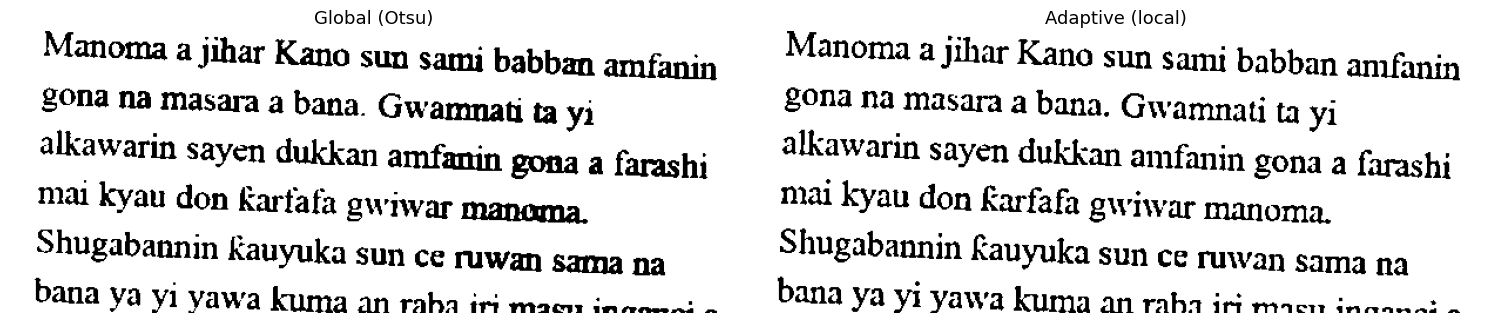

In [11]:
adaptive = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, 31, 15)
show(bw[zoom], adaptive[zoom], titles=["Global (Otsu)", "Adaptive (local)"], height=4)

## A2. Layout analysis — finding the text
Before reading, an OCR engine splits the page into columns, blocks, lines and words. Newspapers with several columns are where the reading order often goes wrong. Tesseract can show the word boxes it found:

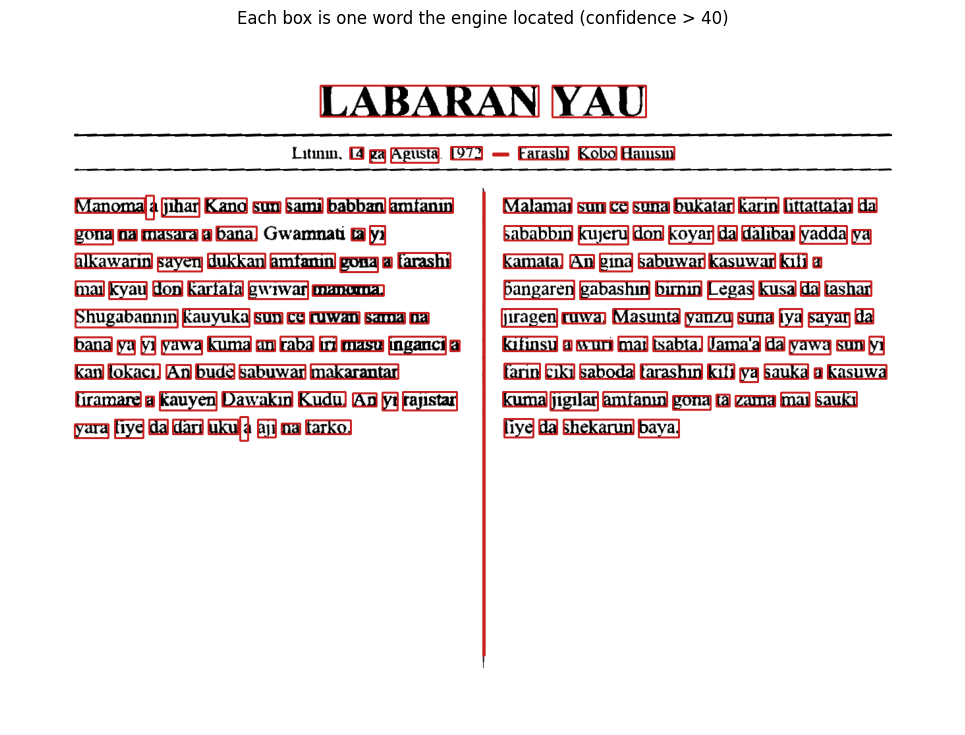

In [12]:
boxes = pytesseract.image_to_data(straight, lang="eng", output_type=pytesseract.Output.DICT)
overlay = cv2.cvtColor(straight, cv2.COLOR_GRAY2BGR)
for i, conf in enumerate(boxes["conf"]):
    if int(conf) > 40:
        x, y, bw_, bh = boxes["left"][i], boxes["top"][i], boxes["width"][i], boxes["height"][i]
        cv2.rectangle(overlay, (x, y), (x + bw_, y + bh), (200, 30, 30), 2)
plt.figure(figsize=(14, 9))
plt.imshow(overlay)
plt.axis("off")
plt.title("Each box is one word the engine located (confidence > 40)")
plt.show()

## A3. Neural OCR
Modern OCR systems (TrOCR, docTR, Surya, and the Google and Azure APIs) replace this hand-tuned pipeline with trained models. They handle damaged pages and handwriting much better — but they need even more training data, which most African languages do not have yet. To try one on a Colab GPU:

```python
# !pip install python-doctr[torch]
# from doctr.io import DocumentFile
# from doctr.models import ocr_predictor
# result = ocr_predictor(pretrained=True)(DocumentFile.from_images([f"{DATA}/newspaper_raw.png"]))
```

## A4. How this demo was made
The "1972 newspaper" was created for this workshop and then artificially aged by [`scripts/make_ocr_assets.py`](../scripts/make_ocr_assets.py). That is how we know the exact ground truth and can show honest error rates. A real archive has no ground truth until a person writes it. Tools like [AfriAnnotate](https://label.afriannotate.org) support that work: the OCR engine suggests text, people correct it, and the corrected text becomes training data for better models.

## A5. Where to go next
- [Tesseract language models](https://github.com/tesseract-ocr/tessdata) — see which languages have a model and which do not
- [Masakhane](https://www.masakhane.io/) — a grassroots community for NLP in African languages
- [Lacuna Fund](https://lacunafund.org/) — funds the creation of African language datasets
- [British Library Endangered Archives Programme](https://eap.bl.uk/) — digitized African newspapers and manuscripts